# Weather NLU - Intent, Action & Entity Extraction

Trains and exports the WeatherBot NLU model against the 4 targets fixed by **MODEL_RULES.md**:

| Target | Rule | Type |
| :-- | :-- | :-- |
| `weather_intent` | 2.1 (14 classes) | classification |
| `action` | 3.1 (3 classes) | classification |
| `LOCATION` | 4.1 | raw text spans (BIO tagger) |
| `TIME` | 4.2 | raw text spans (BIO tagger + clock regex) |

| Split | File | Role |
| :-- | :-- | :-- |
| train | `data/processed/nlu_dataset.csv` | 6300 generated rows - fitting |
| test | `data/processed/nlu_test.csv` | 1512 generated rows, in-distribution held-out; failures feed back into the generator |
| eval | `data/eval_manual.csv` | **hand-written**, 209 rows: typos, ellipsis, ALL CAPS, addresses, odd clock times, thresholds, negation. Templates cannot evaluate templates |

**English is the target language.** The eval set carries 16 Hindi/Telugu code-mixed rows
(`lang == "mixed"`) purely as a diagnostic - they are scored separately and never mixed into
the headline number.

The model itself lives in `src/nlu.py`; this notebook imports it, so what is measured here is
exactly what `python src/nlu.py --export` ships. Everything downstream of the 4 targets
(Solr lat/lng lookup, time normalisation, field-name mapping) is deterministic and out of
scope.

## 1. Imports and Setup

In [1]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.build_dataset import EVAL_MANUAL, SPLITS
from src.data_loader import load_intents_csv
from src.nlu import METRICS_PATH, NLUModel, build_vectorizer, clean_text, evaluate, train
from src.schema import Action, WeatherIntent

TARGETS = ["weather_intent", "action", "location", "time"]
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Splits & Exploratory Data Analysis (EDA)
Load the two generated splits plus the hand-written evaluation set, assert every label sits
inside the V1 taxonomy (Rules 2.1 / 3.1) and that no prompt appears in two splits - an
overlap would silently inflate every score below.

In [2]:
splits = {name: load_intents_csv(ROOT / path) for name, (_, _, path, _) in SPLITS.items()}
splits["eval"] = load_intents_csv(EVAL_MANUAL)   # hand-written, never generated
train_df, test_df, eval_df = splits["train"], splits["test"], splits["eval"]
eval_en = eval_df[eval_df["lang"] == "en"]           # the language we actually target
eval_mixed = eval_df[eval_df["lang"] == "mixed"]     # diagnostic only

for name, df in splits.items():
    off_taxonomy = (set(df["weather_intent"]) - {i.value for i in WeatherIntent}) | (
        set(df["action"]) - {a.value for a in Action}
    )
    assert not off_taxonomy, f"[{name}] labels outside MODEL_RULES taxonomy: {off_taxonomy}"

texts = {name: set(df["text"].str.strip().str.lower()) for name, df in splits.items()}
assert not texts["train"] & texts["test"], "train/test prompt overlap"
assert not texts["eval"] & (texts["train"] | texts["test"]), "eval prompt overlap"

print(pd.DataFrame({
    name: {
        "rows": len(df),
        "intents": df["weather_intent"].nunique(),
        "actions": df["action"].nunique(),
        "no LOCATION span": int((df["location"].str.len() == 0).sum()),
        "no TIME span": int((df["time"].str.len() == 0).sum()),
        "multi-location": int((df["location"].str.len() > 1).sum()),
    }
    for name, df in splits.items()
}))
print(f"\neval languages: {len(eval_en)} English, {len(eval_mixed)} code-mixed")
display(train_df.head(5))

                  train  test  eval
rows               6300  1512   209
intents              14    14    14
actions               3     3     3
no LOCATION span    655   160    17
no TIME span       1241   278    32
multi-location     1869   439    33

eval languages: 193 English, 16 code-mixed


,text,weather_intent,action,location,time
0,differece in minimum temperature betwene bhadv...,TEMPERATURE_MIN,COMPARE,"[bhadvan, motlapalle, jayashankar bhupalapally]",[10:30 am]
1,Ping me about the min temperature in my vilagg...,TEMPERATURE_MIN,ALERT,[my vilagge],[next week]
2,how does the weathre now in my farm compare wi...,CURRENT_CONDITIONS,COMPARE,"[my farm, mizoram]",[7 pm to 9:30 pm]
3,flag the weather otlook by 8 pm,FORECAST,ALERT,[],[8 pm]
4,Tel me wind blows from aroud here tmrw,WIND_DIRECTION,GET,[here],[tmrw]


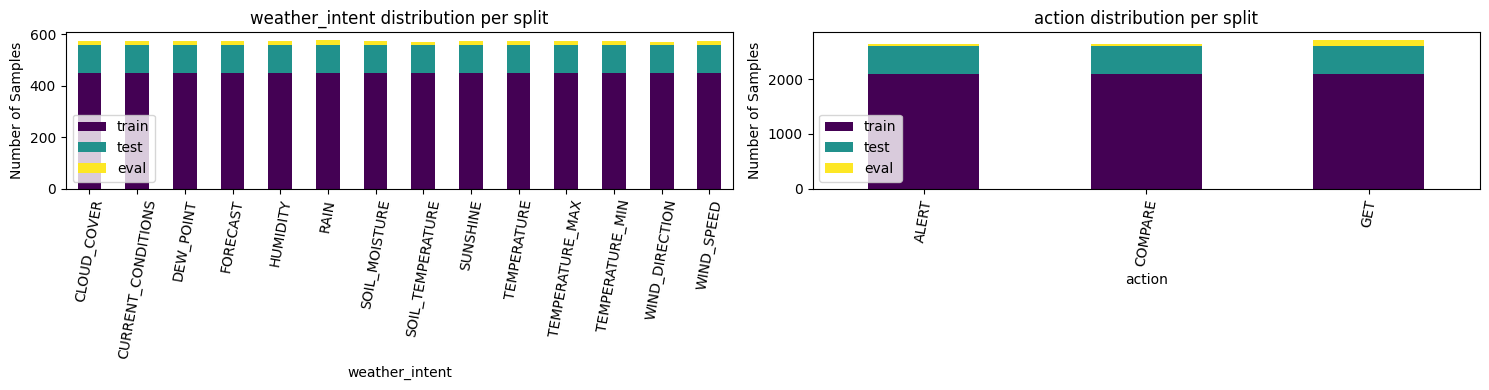

eval entity spans: 126, unseen in train/test: 87
examples: ['10:20 am', '11:59 pm', '1:05 pm', '2:15 pm', '3:35 pm', '4 am to 7 am', '4:20 am', '5 day']


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, col in zip(axes, ["weather_intent", "action"]):
    counts = pd.DataFrame({name: df[col].value_counts() for name, df in splits.items()})
    counts.plot.bar(ax=ax, stacked=True, colormap="viridis", rot=80)
    ax.set_title(f"{col} distribution per split")
    ax.set_ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# The eval set only measures generalization while its entity spans stay unseen in training.
eval_spans = {s.lower() for spans in eval_df["location"] + eval_df["time"] for s in spans}
seen_spans = {s.lower() for df in (train_df, test_df)
              for spans in df["location"] + df["time"] for s in spans}
held_out = eval_spans - seen_spans
print(f"eval entity spans: {len(eval_spans)}, unseen in train/test: {len(held_out)}")
print("examples:", sorted(held_out)[:8])

## 3. Preprocessing & Features
`clean_text()` and the vectorizer come from `src/nlu.py`, so the notebook cannot drift from
the exported model. Word n-grams carry phrasing; **character n-grams carry spelling** -
`temprature` is an unseen token to a word model, but shares most of its character n-grams
with `temperature`. That single change lifted English intent accuracy from 90.0% to 95.3%
once the training data started containing real typos.

In [4]:
vectorizer = build_vectorizer()
X = {"train": vectorizer.fit_transform(train_df["text"].apply(clean_text))}
for name, df in [("test", test_df), ("eval", eval_df)]:
    X[name] = vectorizer.transform(df["text"].apply(clean_text))

display(train_df[["text", "weather_intent", "action", "location", "time"]].head(5))
print({name: matrix.shape for name, matrix in X.items()})
print("word features:", len(vectorizer.transformer_list[0][1].vocabulary_),
      " char features:", len(vectorizer.transformer_list[1][1].vocabulary_))

,text,weather_intent,action,location,time
0,differece in minimum temperature betwene bhadv...,TEMPERATURE_MIN,COMPARE,"[bhadvan, motlapalle, jayashankar bhupalapally]",[10:30 am]
1,Ping me about the min temperature in my vilagg...,TEMPERATURE_MIN,ALERT,[my vilagge],[next week]
2,how does the weathre now in my farm compare wi...,CURRENT_CONDITIONS,COMPARE,"[my farm, mizoram]",[7 pm to 9:30 pm]
3,flag the weather otlook by 8 pm,FORECAST,ALERT,[],[8 pm]
4,Tel me wind blows from aroud here tmrw,WIND_DIRECTION,GET,[here],[tmrw]


{'train': (6300, 44083), 'test': (1512, 44083), 'eval': (209, 44083)}
word features: 23540  char features: 20543


## 4. Model Selection
Cross-validated inside the train split only, on `weather_intent` (the harder of the two
classifiers), on a subsample to keep the notebook quick. Linear SVC has won every run, which
is why `src/nlu.py` fits it directly.

  Linear SVC                  94.10%
  Logistic Regression         93.70%
  Multinomial Naive Bayes     87.47%


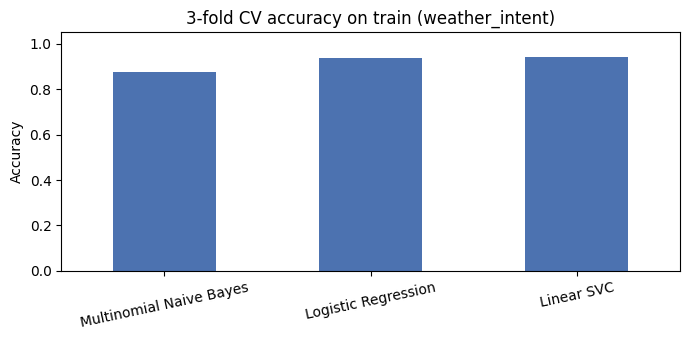

In [5]:
sample = train_df.sample(3000, random_state=42)
X_sample = vectorizer.transform(sample["text"].apply(clean_text))

MODELS = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": SVC(kernel="linear", random_state=42),
}
cv_scores = {name: cross_val_score(model, X_sample, sample["weather_intent"], cv=3).mean()
             for name, model in MODELS.items()}
for name, score in sorted(cv_scores.items(), key=lambda kv: -kv[1]):
    print(f"  {name:26s} {score:7.2%}")

ax = pd.Series(cv_scores).plot.bar(figsize=(7, 3.5), ylim=(0, 1.05), rot=12, color="#4c72b0",
                                   title="3-fold CV accuracy on train (weather_intent)")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 5. Train the Exported Model
`train()` fits the vectorizer, both classifiers and the span tagger - the same call
`python src/nlu.py --export` makes.

In [6]:
model = train(train_df)
print(type(model).__name__, "->", ", ".join(TARGETS))

trained on 6300 rows | tagger min_word_freq=160 (67 words kept)
NLUModel -> weather_intent, action, location, time


## 6. Held-out Accuracy
`all 4 targets` is the metric that matters: it is what the deterministic layer downstream
consumes, and a single wrong span ruins the row. **`eval (English)` is the headline**;
the code-mixed row is a diagnostic, not a target.

,rows,intent,action,location F1,time F1,all 4 targets
test (generated),1512.0,0.9795,0.9954,0.9670,0.9900,0.9312
eval (English),193.0,0.9534,0.9793,0.9741,0.9725,0.8808
eval (code-mixed),16.0,0.7500,0.3125,0.7895,0.0000,0.0000



=== weather_intent on eval (English) ===
                    precision    recall  f1-score   support

       CLOUD_COVER       0.93      1.00      0.96        13
CURRENT_CONDITIONS       0.92      1.00      0.96        12
         DEW_POINT       1.00      1.00      1.00        13
          FORECAST       0.93      1.00      0.96        13
          HUMIDITY       1.00      1.00      1.00        15
              RAIN       0.95      1.00      0.97        18
     SOIL_MOISTURE       1.00      0.86      0.92        14
  SOIL_TEMPERATURE       1.00      1.00      1.00        12
          SUNSHINE       1.00      1.00      1.00        14
       TEMPERATURE       0.86      0.86      0.86        14
   TEMPERATURE_MAX       0.92      0.86      0.89        14
   TEMPERATURE_MIN       1.00      0.93      0.96        14
    WIND_DIRECTION       0.92      0.92      0.92        12
        WIND_SPEED       0.93      0.93      0.93        15

          accuracy                           0.95       

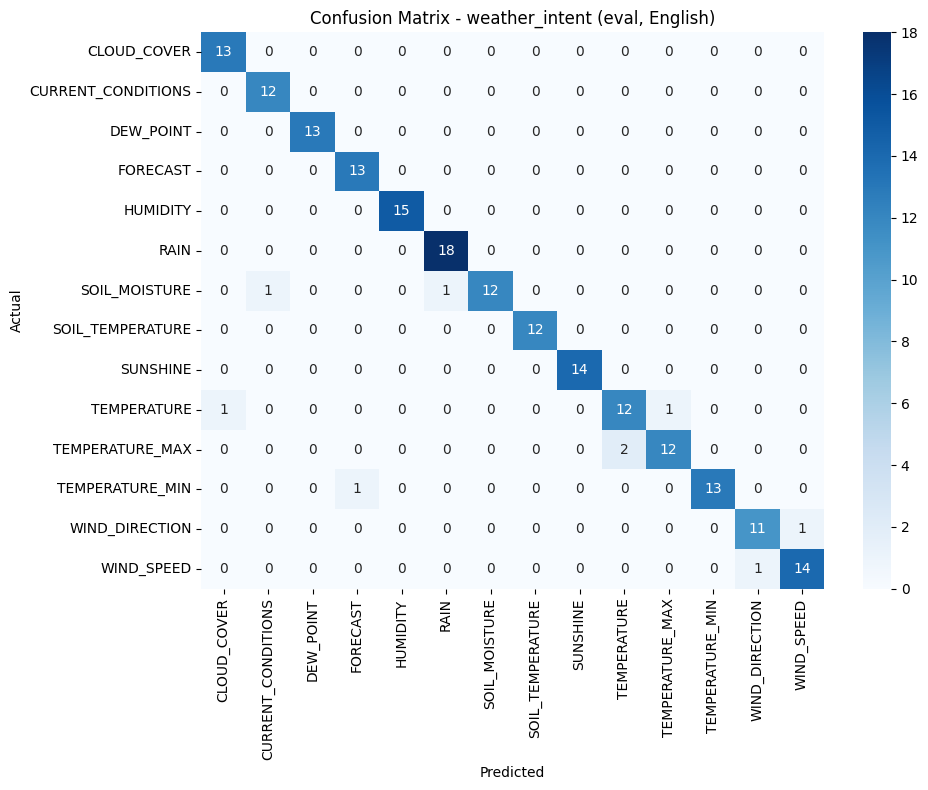


=== action on eval (English) ===
              precision    recall  f1-score   support

       ALERT       1.00      0.98      0.99        45
     COMPARE       0.94      1.00      0.97        46
         GET       0.99      0.97      0.98       102

    accuracy                           0.98       193
   macro avg       0.98      0.98      0.98       193
weighted avg       0.98      0.98      0.98       193



In [7]:
report = {
    "test (generated)": evaluate(model, test_df),
    "eval (English)": evaluate(model, eval_en),
    "eval (code-mixed)": evaluate(model, eval_mixed),
}
summary = pd.DataFrame({
    name: {
        "rows": scores["rows"],
        "intent": scores["weather_intent_accuracy"],
        "action": scores["action_accuracy"],
        "location F1": scores["location_span"]["f1"],
        "time F1": scores["time_span"]["f1"],
        "all 4 targets": scores["all_four_targets"],
    }
    for name, scores in report.items()
}).T
display(summary)

for target in ["weather_intent", "action"]:
    predictions = [getattr(model.predict(text), target).value for text in eval_en["text"]]
    print(f"\n=== {target} on eval (English) ===")
    print(classification_report(eval_en[target], predictions, zero_division=0))
    if target == "weather_intent":
        labels = sorted(set(eval_en[target]) | set(predictions))
        plt.figure(figsize=(10, 8))
        sns.heatmap(confusion_matrix(eval_en[target], predictions, labels=labels), annot=True,
                    fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
        plt.title("Confusion Matrix - weather_intent (eval, English)")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

## 7. Entity Extraction - Tagger vs the Gazetteer it Replaced
The tagger (`src/tagger.py`) labels every token `O` / `B-LOC` / `I-LOC` / `B-TIME` / `I-TIME`
from context and word shape, then decodes back to verbatim slices; clock and duration
expressions get a deterministic regex pass that wins on overlap.

Rare words are hidden behind `<rare>` while fitting, so the model cannot pass training by
memorising village names. The cut is chosen by `choose_min_word_freq()` from the **training
split** - the smallest cut at which no real place name survives in the vocabulary. The eval
set is never consulted, so the numbers stay honest.

In [8]:
# --- baseline: the gazetteer this replaced --------------------------------------
GAZETTEER = {col: sorted({s for spans in train_df[col] for s in spans}, key=len, reverse=True)
             for col in ["location", "time"]}
PATTERNS = {col: [re.compile(rf"\b{re.escape(s)}\b", re.I) for s in spans]
            for col, spans in GAZETTEER.items()}


def gazetteer_extract(text, col):
    """Non-overlapping memorised spans, verbatim, in order of appearance."""
    taken = []
    for pattern in PATTERNS[col]:
        for m in pattern.finditer(text):
            if not any(m.start() < end and start < m.end() for start, end in taken):
                taken.append((m.start(), m.end()))
    return [text[s:e] for s, e in sorted(taken)]


def span_f1(rows, col, predict):
    tp = fp = fn = exact = 0
    for text, gold in zip(rows["text"], rows[col]):
        g = Counter(s.lower() for s in gold)
        p = Counter(s.lower() for s in predict(text, col))
        hit = sum((g & p).values())
        tp, fp, fn = tp + hit, fp + sum(p.values()) - hit, fn + sum(g.values()) - hit
        exact += g == p
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "span_f1": f1, "exact_match": exact / len(rows)}


tagger_extract = lambda text, col: model.tagger.predict(text)[col]
print(f"tagger vocabulary: {len(model.tagger.vocab)} words kept, everything else is <rare>")
display(pd.DataFrame({
    (name, col, extractor): span_f1(rows, col, predict)
    for name, rows in [("test", test_df), ("eval (English)", eval_en)]
    for col in ["location", "time"]
    for extractor, predict in [("gazetteer", gazetteer_extract), ("tagger", tagger_extract)]
}).T.round(3))

tagger vocabulary: 67 words kept, everything else is <rare>


precision  recall  span_f1  exact_match
test           location gazetteer      0.953   0.870    0.910        0.849
                        tagger         0.968   0.966    0.967        0.965
               time     gazetteer      0.977   1.000    0.988        0.979
                        tagger         0.986   0.994    0.990        0.988
eval (English) location gazetteer      0.906   0.136    0.237        0.228
                        tagger         0.976   0.972    0.974        0.974
               time     gazetteer      0.975   0.872    0.920        0.881
                        tagger         0.957   0.989    0.973        0.953

## 8. Full NLU Pipeline
`model.predict()` returns the structured output of Rule 6.1, validated by the `NLUOutput`
pydantic model. `model.confidence()` is the hook for a downstream "ask the user" fallback.

In [9]:
SAMPLE_QUERIES = [
    "Will it rain in Rajahmundry tomorrow morning?",
    "Compare the maximum temperature in Hyderabad and Vizag next week",
    "What is the soil moisture in my field right now?",
    "Alert me if the wind speed is unusual in Kakinada tonight",
    "whats the temprature in Peddapuram, East Godavari at 6:45 pm",
    "min temp in Tirupati on Friday",
]

print("Sample Query Predictions:")
print("-" * 70)
for query in SAMPLE_QUERIES:
    print(f"Query: {query!r}   (intent confidence {model.confidence(query):.1%})")
    print(f"  -> {model.predict(query).model_dump_json()}")
    print("-" * 70)

Sample Query Predictions:
----------------------------------------------------------------------
Query: 'Will it rain in Rajahmundry tomorrow morning?'   (intent confidence 99.9%)
  -> {"weather_intent":"RAIN","action":"GET","entities":{"location":["Rajahmundry"],"time":["tomorrow morning"],"time_normalized":["tomorrow morning"]}}
----------------------------------------------------------------------
Query: 'Compare the maximum temperature in Hyderabad and Vizag next week'   (intent confidence 100.0%)
  -> {"weather_intent":"TEMPERATURE_MAX","action":"COMPARE","entities":{"location":["Hyderabad","Vizag"],"time":["next week"],"time_normalized":["next week"]}}
----------------------------------------------------------------------
Query: 'What is the soil moisture in my field right now?'   (intent confidence 100.0%)
  -> {"weather_intent":"SOIL_MOISTURE","action":"GET","entities":{"location":["my field"],"time":["right now"],"time_normalized":["now"]}}
------------------------------------

## 9. Failure Harvest - the Improvement Loop
Every row the model gets wrong on any of the 4 targets, written to
`data/processed/hard_cases.csv`.

**Read the English failures, fix the generator, rebuild, retrain.** Never copy an eval row
into the generator: the moment training material reaches `data/eval_manual.csv`, it stops
measuring anything. Code-mixed failures are expected - that language is not a V1 target.

In [10]:
def audit(rows, label):
    predictions = [model.predict(text) for text in rows["text"]]
    out = rows[["text"] + TARGETS].copy()
    out["pred_weather_intent"] = [p.weather_intent.value for p in predictions]
    out["pred_action"] = [p.action.value for p in predictions]
    out["pred_location"] = [p.entities.location for p in predictions]
    out["pred_time"] = [p.entities.time for p in predictions]
    norm = lambda v: sorted(s.lower() for s in v) if isinstance(v, list) else v
    out["missed"] = [",".join(c for c in TARGETS if norm(row[c]) != norm(row["pred_" + c]))
                     for _, row in out.iterrows()]
    out["split"] = label
    return out


audits = {label: audit(rows, label) for label, rows in
          [("test", test_df), ("eval-en", eval_en), ("eval-mixed", eval_mixed)]}
print(pd.DataFrame({
    label: {"rows": len(a), "all 4 correct": (a["missed"] == "").mean(),
            "rows to fix": int((a["missed"] != "").sum())}
    for label, a in audits.items()
}).T.to_string())

hard = pd.concat([a[a["missed"] != ""] for a in audits.values()])
hard_path = ROOT / "data/processed/hard_cases.csv"
hard.to_csv(hard_path, index=False)
print(f"\nWrote {len(hard)} hard cases -> {hard_path}")
print("\nWhich target misses, by split:")
print(hard.groupby("split")["missed"].value_counts().to_string())
display(hard[hard["split"] == "eval-en"][
    ["text", "missed", "location", "pred_location", "time", "pred_time"]].head(10))

              rows  all 4 correct  rows to fix
test        1512.0       0.931217        104.0
eval-en      193.0       0.880829         23.0
eval-mixed    16.0       0.000000         16.0

Wrote 143 hard cases -> /Users/udaychittala/ML Projects/WeatherBot/data/processed/hard_cases.csv

Which target misses, by split:
split       missed                        
eval-en     time                               7
            weather_intent                     7
            location                           4
            action                             2
            action,location,time               1
            weather_intent,action              1
            weather_intent,time                1
eval-mixed  action,time                        6
            time                               3
            action,location,time               2
            location,time                      1
            weather_intent,action              1
            weather_intent,action,location     1
  

,text,missed,location,pred_location,time,pred_time
29,how hot is it rn in Muzaffarpur,time,[Muzaffarpur],[Muzaffarpur],[rn],[]
35,how warm will it be day after tomorrow in Remta,weather_intent,[Remta],[Remta],[day after tomorrow],[day after tomorrow]
36,"Compare the temperature in Haryana, Bihar and ...",location,"[Haryana, Bihar, Tripura]","[Haryana, Bihar, Tripura]",[today],[today]
37,is it hotter in Mendoza or San Juan this week,weather_intent,"[Mendoza, San Juan]","[Mendoza, San Juan]",[this week],[this week]
39,alert me if the temperature crosses 42 degrees...,time,[Iragavaram],[Iragavaram],[tomorrow],"[42, tomorrow]"
54,frost alert for my farm tomorrow morning,weather_intent,[my farm],[my farm],[tomorrow morning],[tomorrow morning]
63,how hot will it get in Kantamegha between 11 A...,"weather_intent,action",[Kantamegha],[Kantamegha],"[11 AM, 4 PM]","[11 AM, 4 PM]"
67,alert me if the max temp goes above 45 degrees...,time,[Buxar],[Buxar],[],[45]
68,heat warning for my village this week?,weather_intent,[my village],[my village],[this week],[this week]
79,"compare rainfall in East Godavari, Perambalur ...",location,"[East Godavari, Perambalur, Tinsukia]","[East Godavari, Perambalur, Tinsukia]",[this week],[this week]


## 10. Export
Writes `models/nlu_pipeline.joblib` (vectorizer + both classifiers + tagger) and
`models/metrics.json`. Identical to `python src/nlu.py --export`.

Serving needs `src/` importable - the tagger's feature builder lives in `src/tagger.py`, so
inference and training stay on byte-identical features:

```python
from src.nlu import NLUModel
model = NLUModel.load()
model.predict("will it rain in Guntur tomorrow?")     # -> NLUOutput
```

In [11]:
bundle_path = model.save()
report["eval (all)"] = evaluate(model, eval_df)
METRICS_PATH.write_text(json.dumps({"train_rows": len(train_df), **report}, indent=2) + "\n")

print(f"saved {bundle_path}")
print(f"saved {METRICS_PATH}")

reloaded = NLUModel.load(bundle_path)
check = reloaded.predict("will it rain in Guntur at 6:45 pm tomorrow?")
assert check.entities.location == ["Guntur"], check
print("\nreload check ->", check.model_dump_json())

saved /Users/udaychittala/ML Projects/WeatherBot/models/nlu_pipeline.joblib
saved /Users/udaychittala/ML Projects/WeatherBot/models/metrics.json

reload check -> {"weather_intent":"RAIN","action":"GET","entities":{"location":["Guntur"],"time":["6:45 pm","tomorrow"],"time_normalized":["18:45","tomorrow"]}}
